In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB


In [39]:
df=pd.read_csv("/content/sample_5000.csv")


In [40]:
X = df.drop("Label", axis=1)
y = df["Label"]
X = X.replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y)

# ------------               poisoning    ------------     

In [41]:
poisoning_rate = 0.04
n_poison = int(poisoning_rate * len(y_train))
poison_indices = np.random.choice(len(y_train), n_poison, replace=False)
y_train_poisoned = y_train.copy()
y_train_poisoned.iloc[poison_indices] = 1 - y_train_poisoned.iloc[poison_indices]

print(f"تم تسميم {n_poison} عينة في بيانات التدريب.")

تم تسميم 224 عينة في بيانات التدريب.


# ------------               RFC     ------------     

Confusion Matrix RFC:
 [[1199    1]
 [  42 1162]]
Accuracy: 0.9821131447587355
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1200
           1       1.00      0.97      0.98      1204

    accuracy                           0.98      2404
   macro avg       0.98      0.98      0.98      2404
weighted avg       0.98      0.98      0.98      2404



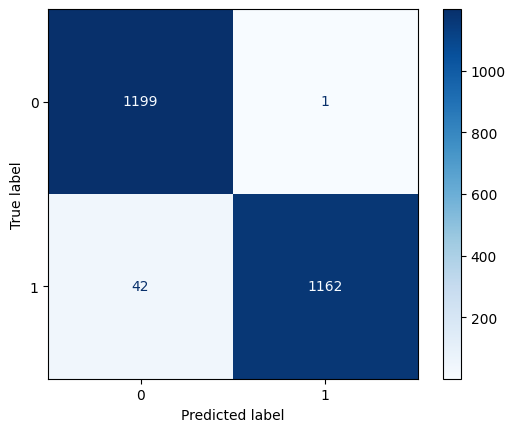

In [42]:
Rmodel = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42
)

Rmodel.fit(X_train, y_train_poisoned)
y_pred = Rmodel.predict(X_test)
cmR = confusion_matrix(y_test, y_pred)

print("Confusion Matrix RFC:\n", cmR)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


disp = ConfusionMatrixDisplay(confusion_matrix=cmR, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

In [43]:
train_pred = Rmodel.predict(X_train)
print("Training Accuracy RFC:", accuracy_score(y_train_poisoned, train_pred))
print("Testing Accuracy  RFC :", accuracy_score(y_test, y_pred))

Training Accuracy RFC: 0.9427603423680456
Testing Accuracy  RFC : 0.9821131447587355


> # ------------               XGBOOST     ------------     


Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Best Score: 0.9416881731201929
Confusion Matrix XGBOOST:
 [[1195    5]
 [  41 1163]]
Accuracy: 0.980865224625624
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1200
           1       1.00      0.97      0.98      1204

    accuracy                           0.98      2404
   macro avg       0.98      0.98      0.98      2404
weighted avg       0.98      0.98      0.98      2404



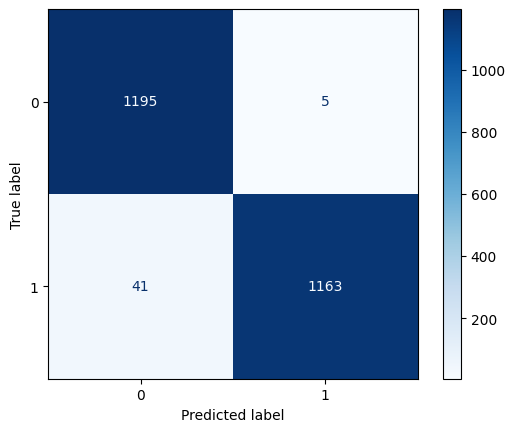

In [44]:
grid_parameters = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.01, 0.2],
    'max_depth': [3, 5, 7]
}


grid_model = GridSearchCV(
    XGBClassifier(random_state=0),
    grid_parameters,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_model.fit(X_train, y_train_poisoned)
print("Best Parameters:", grid_model.best_params_)
print("Best Score:", grid_model.best_score_)
y_pred = grid_model.predict(X_test)


y_pred = grid_model.predict(X_test)
cmG = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)



print("Confusion Matrix XGBOOST:\n", cmG)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cmG, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

In [45]:
train_pred = grid_model.predict(X_train)
print("Training Accuracy XGBOOST:", accuracy_score(y_train_poisoned, train_pred))
print("Testing Accuracy XGBOOST:", accuracy_score(y_test, y_pred))

Training Accuracy XGBOOST: 0.9420470756062768
Testing Accuracy XGBOOST: 0.980865224625624


# ------------ SVM ------------





Accuracy SVM: 0.9646422628951747

Confusion Matrix:
 [[1182   18]
 [  67 1137]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97      1200
           1       0.98      0.94      0.96      1204

    accuracy                           0.96      2404
   macro avg       0.97      0.96      0.96      2404
weighted avg       0.97      0.96      0.96      2404



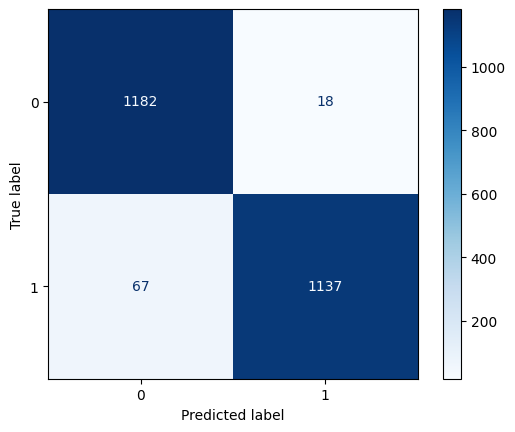

In [46]:
smodel = SVC(kernel='rbf', C=1.0, gamma='scale')
smodel.fit(X_train, y_train_poisoned)
y_pred = smodel.predict(X_test)


CMS = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)


print("Accuracy SVM:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=CMS, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

In [47]:
train_pred = smodel.predict(X_train)
print("Training Accuracy SVM:", accuracy_score(y_train_poisoned, train_pred))
print("Testing Accuracy SVM:", accuracy_score(y_test, y_pred))

Training Accuracy SVM: 0.9288516405135521
Testing Accuracy SVM: 0.9646422628951747


------------               Logistic Regression    ------------    

--- Logistic Regression Results ---
Training Accuracy LR: 0.9361626248216833
Testing Accuracy LR: 0.9746256239600666

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98      1200
           1       1.00      0.95      0.97      1204

    accuracy                           0.97      2404
   macro avg       0.98      0.97      0.97      2404
weighted avg       0.98      0.97      0.97      2404



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


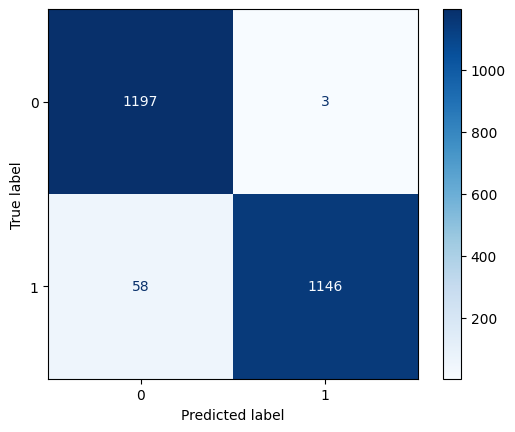

In [49]:
clf = LogisticRegression(max_iter=10000, random_state=0)
clf.fit(X_train, y_train_poisoned)
y_pred = clf.predict(X_test)
train_pred = clf.predict(X_train)
CML = confusion_matrix(y_test, y_pred)

print("--- Logistic Regression Results ---")
print("Training Accuracy LR:", accuracy_score(y_train_poisoned, train_pred))
print("Testing Accuracy LR:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=CML, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

In [50]:
train_pred = clf.predict(X_train)
print("Training Accuracy LogisticRegression:", accuracy_score(y_train_poisoned, train_pred))
print("Testing Accuracy LogisticRegression:", accuracy_score(y_test, y_pred))

Training Accuracy LogisticRegression: 0.9361626248216833
Testing Accuracy LogisticRegression: 0.9746256239600666


# ------------               LightGBM    ------------



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2832, number of negative: 2776
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001031 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1515
[LightGBM] [Info] Number of data points in the train set: 5608, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.504993 -> initscore=0.019972
[LightGBM] [Info] Start training from score 0.019972
Accuracy  LightGBM: 0.9775374376039934

Confusion Matrix:
 [[1194    6]
 [  48 1156]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98      1200
           1       0.99      0.96      0.98      1204

    accuracy                           0.98      2404
   macro avg       0.98      0.98     

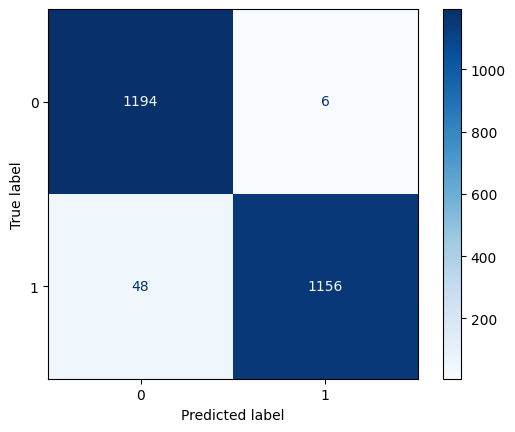

In [51]:
GBMmodel = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

GBMmodel.fit(X_train, y_train_poisoned)

y_pred = GBMmodel.predict(X_test)
CMGBM = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)


print("Accuracy  LightGBM:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=CMGBM, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

In [52]:
train_pred = GBMmodel.predict(X_train)
print("Training Accuracy LightGBM:", accuracy_score(y_train_poisoned, train_pred))
print("Testing Accuracy LightGBM:", accuracy_score(y_test, y_pred))

Training Accuracy LightGBM: 0.956490727532097
Testing Accuracy LightGBM: 0.9775374376039934


# ------------ Naïve Bayes ------------

Accuracy  Naïve Bayes: 0.9721297836938436

Confusion Matrix:
 [[1193    7]
 [  60 1144]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      1200
           1       0.99      0.95      0.97      1204

    accuracy                           0.97      2404
   macro avg       0.97      0.97      0.97      2404
weighted avg       0.97      0.97      0.97      2404



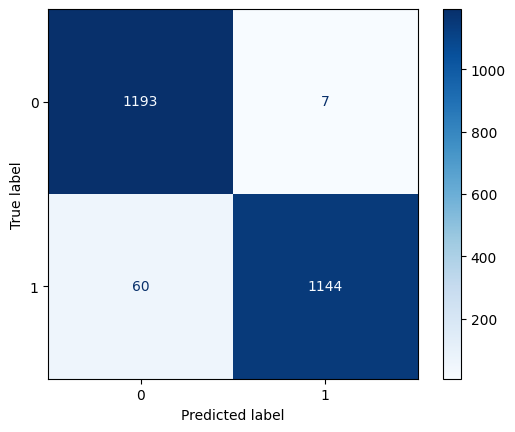

In [53]:
nb_model = GaussianNB(
    var_smoothing=1e-10
)

nb_model.fit(X_train, y_train_poisoned)
y_pred = nb_model.predict(X_test)

CMnb = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)


print("Accuracy  Naïve Bayes:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=CMnb, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()


In [54]:
train_pred = nb_model.predict(X_train)
print("Training Accuracy LightGBM:", accuracy_score(y_train_poisoned, train_pred))
print("Testing Accuracy LightGBM:", accuracy_score(y_test, y_pred))

Training Accuracy LightGBM: 0.9329529243937232
Testing Accuracy LightGBM: 0.9721297836938436
